# 02 — Prophet Forecasting: Baseline -> Tuned

Workflow:
1. Fit a **baseline** Prophet model (defaults + US holidays) on one series, backtest it.
2. **Tune** `changepoint_prior_scale` / `seasonality_prior_scale` via rolling-origin cross-validation, on a *stratified sample* of series (low/medium/high demand variability from notebook 01) — grid-searching all 500 series individually is not worth the compute for a portfolio demo, and picking a representative sample to justify a global parameter choice is itself a realistic production tradeoff worth documenting.
3. Compare baseline vs. tuned backtested accuracy.
4. Forecast forward for every (store, item) series using the winning params, and export a tidy forecast table for the inventory simulation (notebook 03) and Power BI.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import get_series, list_series_keys, load_raw, save_processed, train_test_split_by_date
from src.prophet_pipeline import export_forecast_table, fit_prophet, forecast, grid_search_cv

df = load_raw()
CUTOFF = "2017-06-30"  # holds out ~6 months for backtesting

c:\Users\ntruz\source\repos\sales-forecasting-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Baseline model on one series

17:23:46 - cmdstanpy - INFO - Chain [1] start processing
17:23:51 - cmdstanpy - INFO - Chain [1] done processing


Baseline backtest MAPE: 0.194


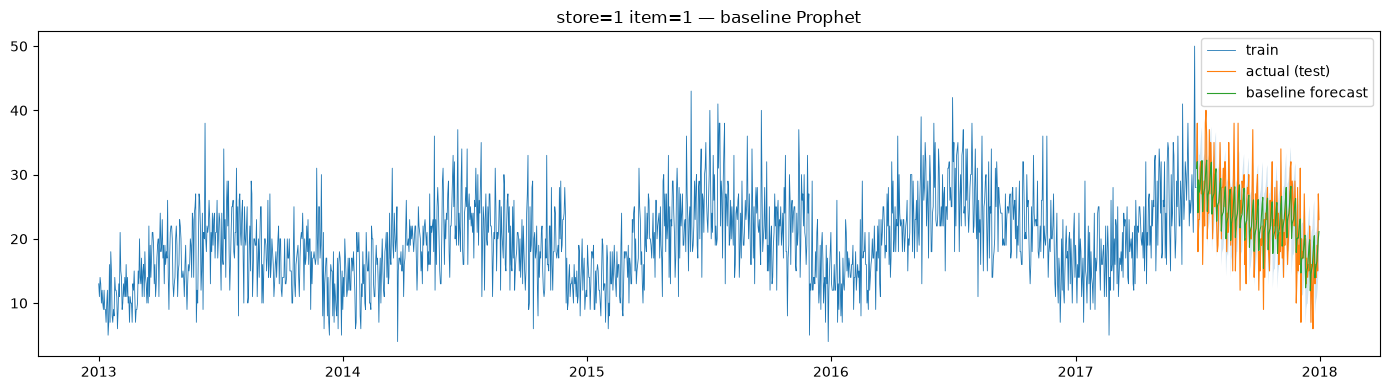

In [2]:
series = get_series(df, store=1, item=1)
train, test = train_test_split_by_date(series, CUTOFF)

baseline_model = fit_prophet(train)
baseline_fcst = forecast(baseline_model, periods=len(test), freq="D")

compare = test.merge(baseline_fcst, on="ds", how="left")
baseline_mape = (compare["y"] - compare["yhat"]).abs().div(compare["y"].replace(0, 1)).mean()
print(f"Baseline backtest MAPE: {baseline_mape:.3f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["ds"], train["y"], label="train", linewidth=0.6)
ax.plot(compare["ds"], compare["y"], label="actual (test)", linewidth=0.8)
ax.plot(compare["ds"], compare["yhat"], label="baseline forecast", linewidth=0.8)
ax.fill_between(compare["ds"], compare["yhat_lower"], compare["yhat_upper"], alpha=0.2)
ax.legend(); ax.set_title("store=1 item=1 — baseline Prophet")
plt.tight_layout()

## Stratified sample for tuning

Pull low/medium/high coefficient-of-variation series from the table saved in notebook 01.

In [3]:
variability = pd.read_parquet(Path.cwd().parent / "data" / "processed" / "series_variability.parquet")
variability = variability.sort_values("cv")
n = len(variability)
sample_idx = [0, n // 4, n // 2, 3 * n // 4, n - 1]  # low -> high CV spread
tuning_sample = variability.iloc[sample_idx][["store", "item", "cv"]]
tuning_sample

,store,item,cv
364,8,15,0.261602
411,9,12,0.273152
344,7,45,0.283933
172,4,23,0.304062
254,6,5,0.373411


## Grid search cross-validation

Uses Prophet's built-in rolling-origin `cross_validation`/`performance_metrics` (see `src/prophet_pipeline.py::grid_search_cv`). This is the expensive cell — grid size x CV folds x sample series.

In [4]:
tuning_rows = []
best_params_per_series = {}

for _, row in tuning_sample.iterrows():
    store, item = int(row["store"]), int(row["item"])
    train_s, _ = train_test_split_by_date(get_series(df, store, item), CUTOFF)
    result = grid_search_cv(train_s)
    best_params_per_series[(store, item)] = result.best_params
    tuning_rows.append({"store": store, "item": item, "cv": row["cv"], **result.best_params})

tuning_summary = pd.DataFrame(tuning_rows)
tuning_summary

17:23:54 - cmdstanpy - INFO - Chain [1] start processing
17:23:54 - cmdstanpy - INFO - Chain [1] done processing
17:24:02 - cmdstanpy - INFO - Chain [1] start processing
17:24:02 - cmdstanpy - INFO - Chain [1] done processing
17:24:09 - cmdstanpy - INFO - Chain [1] start processing
17:24:09 - cmdstanpy - INFO - Chain [1] done processing
17:24:15 - cmdstanpy - INFO - Chain [1] start processing
17:24:15 - cmdstanpy - INFO - Chain [1] done processing
17:24:22 - cmdstanpy - INFO - Chain [1] start processing
17:24:22 - cmdstanpy - INFO - Chain [1] done processing
17:24:29 - cmdstanpy - INFO - Chain [1] start processing
17:24:30 - cmdstanpy - INFO - Chain [1] done processing
17:24:37 - cmdstanpy - INFO - Chain [1] start processing
17:24:37 - cmdstanpy - INFO - Chain [1] done processing
17:24:44 - cmdstanpy - INFO - Chain [1] start processing
17:24:44 - cmdstanpy - INFO - Chain [1] done processing
17:24:51 - cmdstanpy - INFO - Chain [1] start processing
17:24:51 - cmdstanpy - INFO - Chain [1]

,store,item,cv,changepoint_prior_scale,seasonality_prior_scale
0,8,15,0.261602,0.05,1.0
1,9,12,0.273152,0.05,1.0
2,7,45,0.283933,0.10,10.0
3,4,23,0.304062,0.05,10.0
4,6,5,0.373411,0.50,1.0


## Pick a global parameter set

Take the median of the per-series winners (or the mode, if there's an obvious cluster) as the parameter set applied across all 500 series at forecast-generation time. Document the alternative considered: per-series tuning gives marginally better accuracy but doesn't scale, and the accuracy delta on the stratified sample should be checked here before defaulting to "global params good enough".

In [5]:
GLOBAL_PARAMS = {
    "changepoint_prior_scale": tuning_summary["changepoint_prior_scale"].median(),
    "seasonality_prior_scale": tuning_summary["seasonality_prior_scale"].median(),
}
GLOBAL_PARAMS

{'changepoint_prior_scale': np.float64(0.05),
 'seasonality_prior_scale': np.float64(1.0)}

## Baseline vs. tuned — backtested accuracy on the sample

In [6]:
def backtest_mape(store, item, params):
    train_s, test_s = train_test_split_by_date(get_series(df, store, item), CUTOFF)
    model = fit_prophet(train_s, **params)
    fcst = forecast(model, periods=len(test_s))
    compare = test_s.merge(fcst, on="ds", how="left")
    return (compare["y"] - compare["yhat"]).abs().div(compare["y"].replace(0, 1)).mean()

accuracy_rows = []
for _, row in tuning_sample.iterrows():
    store, item = int(row["store"]), int(row["item"])
    accuracy_rows.append({
        "store": store, "item": item,
        "baseline_mape": backtest_mape(store, item, {}),
        "tuned_mape": backtest_mape(store, item, GLOBAL_PARAMS),
    })

accuracy_df = pd.DataFrame(accuracy_rows)
accuracy_df["improvement_pct"] = (
    (accuracy_df["baseline_mape"] - accuracy_df["tuned_mape"]) / accuracy_df["baseline_mape"] * 100
)
accuracy_df

17:32:18 - cmdstanpy - INFO - Chain [1] start processing
17:32:19 - cmdstanpy - INFO - Chain [1] done processing
17:32:19 - cmdstanpy - INFO - Chain [1] start processing
17:32:20 - cmdstanpy - INFO - Chain [1] done processing
17:32:20 - cmdstanpy - INFO - Chain [1] start processing
17:32:20 - cmdstanpy - INFO - Chain [1] done processing
17:32:21 - cmdstanpy - INFO - Chain [1] start processing
17:32:21 - cmdstanpy - INFO - Chain [1] done processing
17:32:22 - cmdstanpy - INFO - Chain [1] start processing
17:32:22 - cmdstanpy - INFO - Chain [1] done processing
17:32:22 - cmdstanpy - INFO - Chain [1] start processing
17:32:23 - cmdstanpy - INFO - Chain [1] done processing
17:32:23 - cmdstanpy - INFO - Chain [1] start processing
17:32:23 - cmdstanpy - INFO - Chain [1] done processing
17:32:24 - cmdstanpy - INFO - Chain [1] start processing
17:32:24 - cmdstanpy - INFO - Chain [1] done processing
17:32:25 - cmdstanpy - INFO - Chain [1] start processing
17:32:25 - cmdstanpy - INFO - Chain [1]

,store,item,baseline_mape,tuned_mape,improvement_pct
0,8,15,0.088062,0.088088,-0.028542
1,9,12,0.098561,0.098502,0.060576
2,7,45,0.109582,0.109448,0.122771
3,4,23,0.155451,0.155156,0.189812
4,6,5,0.256892,0.257094,-0.078596


## Forecast forward for every (store, item) and export

Uses the full history (no holdout) with `GLOBAL_PARAMS`, forecasting 90 days beyond the end of the dataset. This is the table `03_inventory_simulation.ipynb` and the Power BI "Forecast Accuracy" page both consume.

In [7]:
FORECAST_HORIZON_DAYS = 90
all_forecasts = []

for store, item in list_series_keys(df):
    full_series = get_series(df, store, item)
    model = fit_prophet(full_series, **GLOBAL_PARAMS)
    fcst = forecast(model, periods=FORECAST_HORIZON_DAYS)
    all_forecasts.append(export_forecast_table(fcst, store, item, actuals=full_series))

forecast_table = pd.concat(all_forecasts, ignore_index=True)
print(forecast_table.shape)
save_processed(forecast_table, "forecast_all_series")
forecast_table.to_csv(Path.cwd().parent / "outputs" / "forecast_all_series.csv", index=False)

17:32:26 - cmdstanpy - INFO - Chain [1] start processing
17:32:27 - cmdstanpy - INFO - Chain [1] done processing
17:32:27 - cmdstanpy - INFO - Chain [1] start processing
17:32:27 - cmdstanpy - INFO - Chain [1] done processing
17:32:28 - cmdstanpy - INFO - Chain [1] start processing
17:32:28 - cmdstanpy - INFO - Chain [1] done processing
17:32:29 - cmdstanpy - INFO - Chain [1] start processing
17:32:29 - cmdstanpy - INFO - Chain [1] done processing
17:32:29 - cmdstanpy - INFO - Chain [1] start processing
17:32:30 - cmdstanpy - INFO - Chain [1] done processing
17:32:30 - cmdstanpy - INFO - Chain [1] start processing
17:32:30 - cmdstanpy - INFO - Chain [1] done processing
17:32:31 - cmdstanpy - INFO - Chain [1] start processing
17:32:31 - cmdstanpy - INFO - Chain [1] done processing
17:32:32 - cmdstanpy - INFO - Chain [1] start processing
17:32:32 - cmdstanpy - INFO - Chain [1] done processing
17:32:33 - cmdstanpy - INFO - Chain [1] start processing
17:32:33 - cmdstanpy - INFO - Chain [1]

(958000, 7)


**Note on runtime:** fitting 500 Prophet models sequentially takes a while (minutes, not hours, but non-trivial). If iterating, consider running this cell on a subset first (e.g. `list_series_keys(df)[:20]`) and only running the full loop once satisfied with `GLOBAL_PARAMS`.